# Plan d'expérience

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

ant=10
n_iter=50
alpha=1
beta=2
rho=0.1

def ACO(ants, it, alpha, beta, rho):
    return  random.randint(50, 1000)

def execAlgoOneParam(nbIt, arrayParam, name_param):
    LMean, LStd, LMedian, LAbsMedian, LTpsMean = [], [], [], [], []
    for param in arrayParam:
        LRes = []
        LTps = []
        for i in range(nbIt):
            match name_param:
                case "ant":
                    start = time.time()
                    LRes.append(ACO(param, n_iter, alpha, beta, rho))
                    end = time.time()
                case 'it':
                    start = time.time()
                    LRes.append(ACO(ant, param, alpha, beta, rho))
                    end = time.time()
                case "alpha":
                    start = time.time()
                    LRes.append(ACO(ant, n_iter, param, beta, rho))
                    end = time.time()
                case "beta":
                    start = time.time()
                    LRes.append(ACO(ant, n_iter, alpha, param, rho))
                    end = time.time()
                case "rho":
                    start = time.time()
                    LRes.append(ACO(ant, n_iter, alpha, beta, param))
                    end = time.time()

                case _:
                    exit()

            LTps.append(end - start)

        LMean.append(np.mean(LRes))
        LStd.append(np.std(LRes))
        LMedian.append(np.median(LRes))
        LAbsMedian.append(np.mean(np.abs(LRes - np.mean(LRes))))
        LTpsMean.append(np.mean(LTps))

    return LMean, LStd, LMedian, LAbsMedian, LTpsMean



In [22]:
def plotOneParam(arrayParam, LMean, LStd, LMedian, LAbsMedian, LTpsMean, name_param):
    plt.figure(figsize=(14, 10))

    plt.subplot(2, 1, 1)

    # Courbe de moyenne
    plt.plot(arrayParam, LMean, label='Moyenne')

    # Bande écart-type
    LMean = np.array(LMean)
    LStd = np.array(LStd)

    plt.fill_between(
        arrayParam,
        LMean - LStd,
        LMean + LStd,
        alpha=0.3,
        label='Écart-type'
    )

    # Autres métriques (optionnel mais utile)
    plt.plot(arrayParam, LMedian, linestyle='--', label='Médiane')
    plt.plot(arrayParam, LAbsMedian, linestyle=':', label='Écart moyen absolu')

    plt.xlabel(name_param)
    plt.ylabel('Valeurs')
    plt.title(f'Statistiques des résultats ({name_param})')
    plt.legend()
    plt.grid()

    # === SUBPLOT 2 : temps ===
    plt.subplot(2, 1, 2)
    plt.plot(arrayParam, LTpsMean, label='Temps', color='black')

    plt.xlabel(name_param)
    plt.ylabel('Temps (s)')
    plt.title(f'Temps d’exécution ({name_param})')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

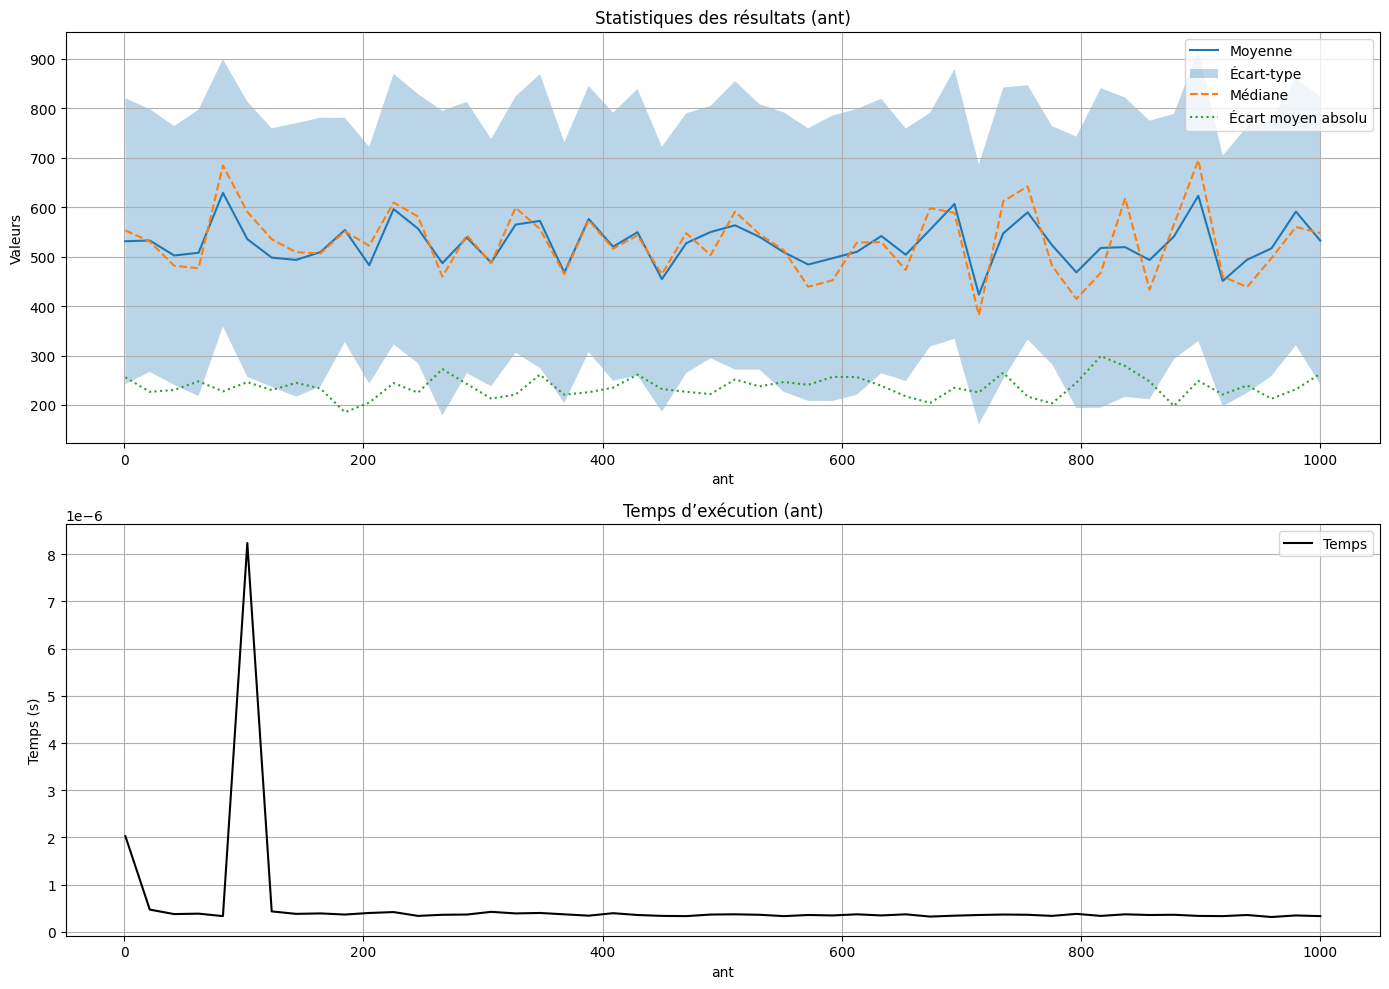

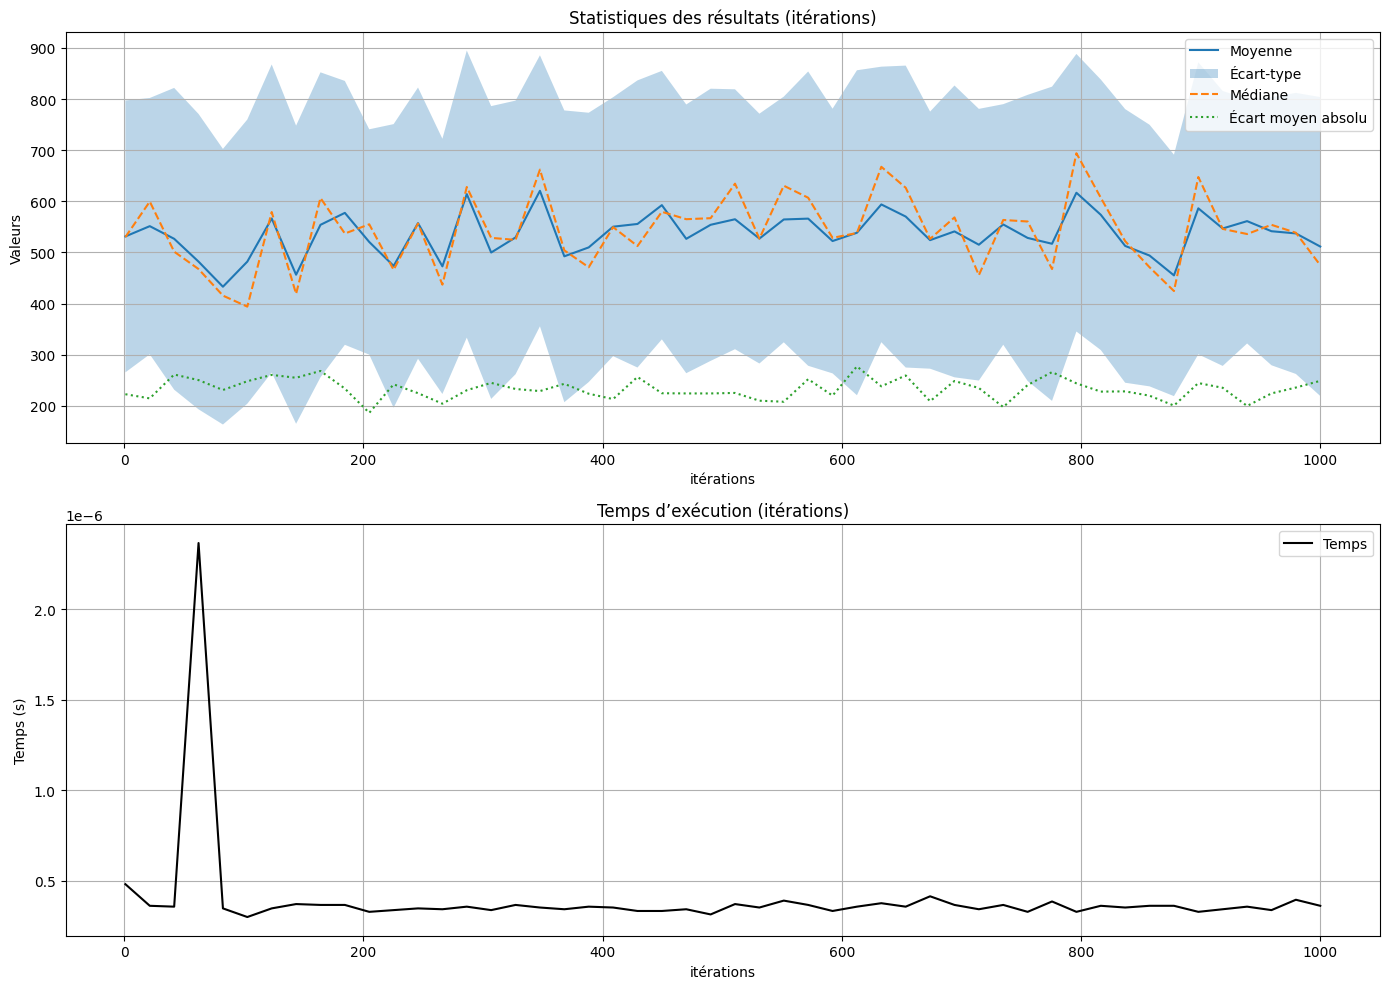

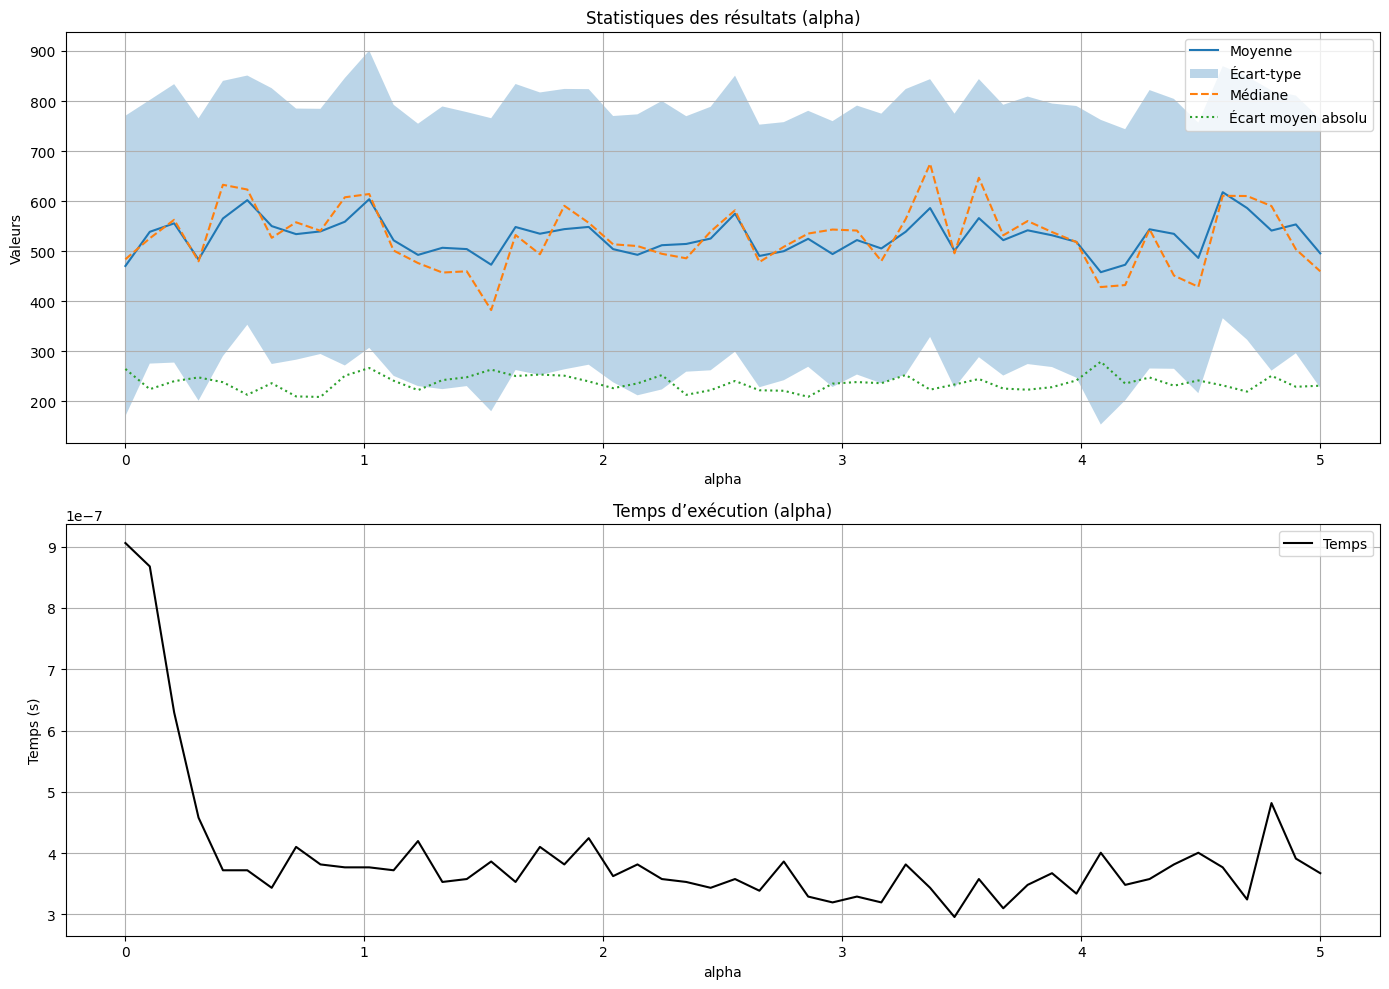

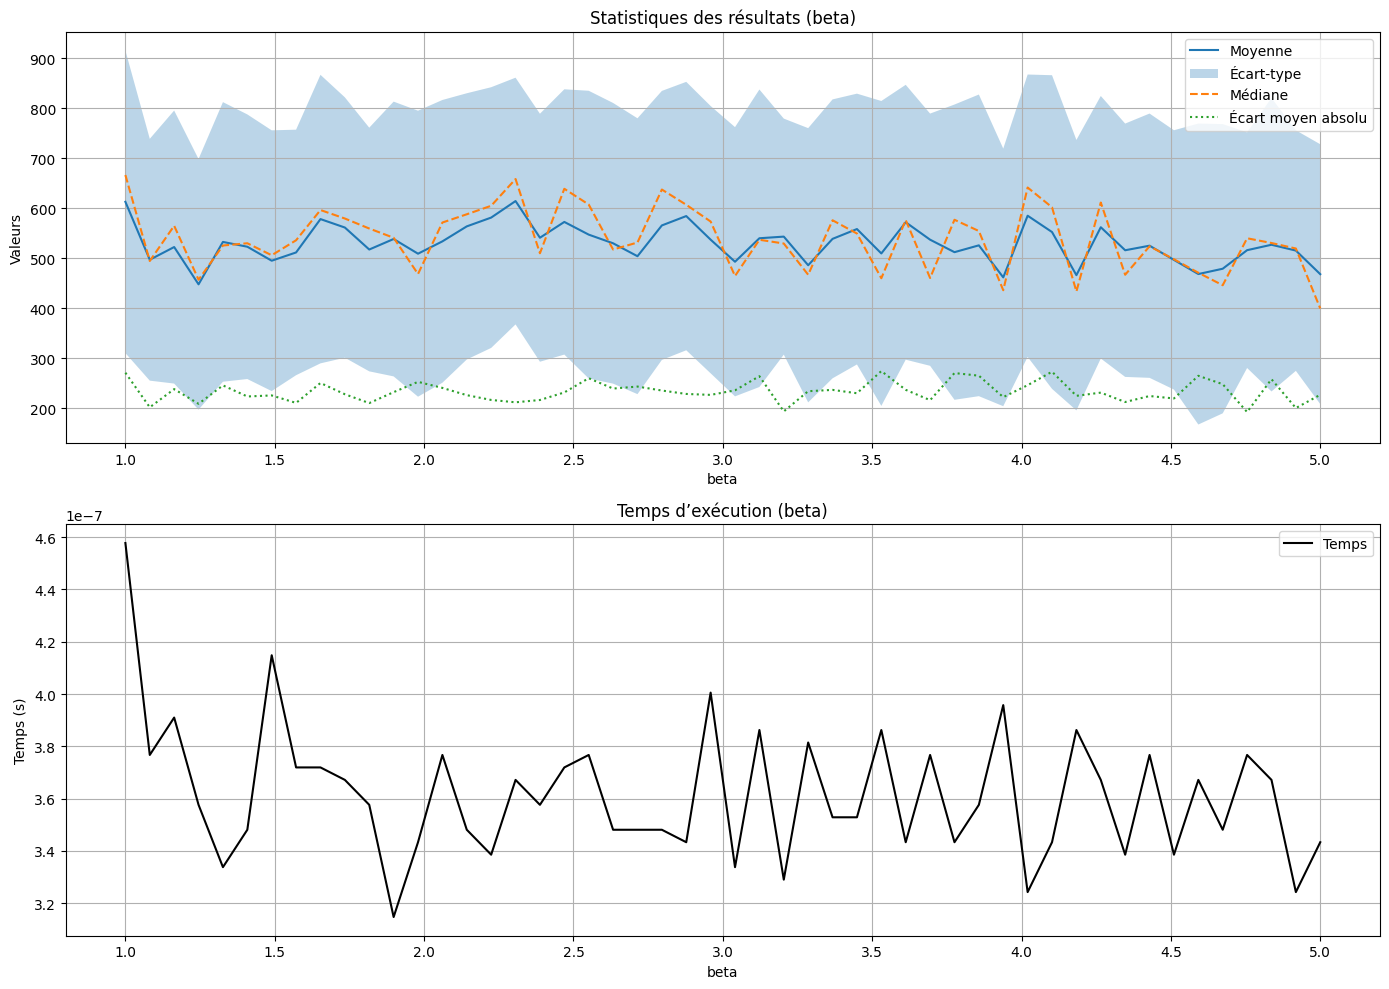

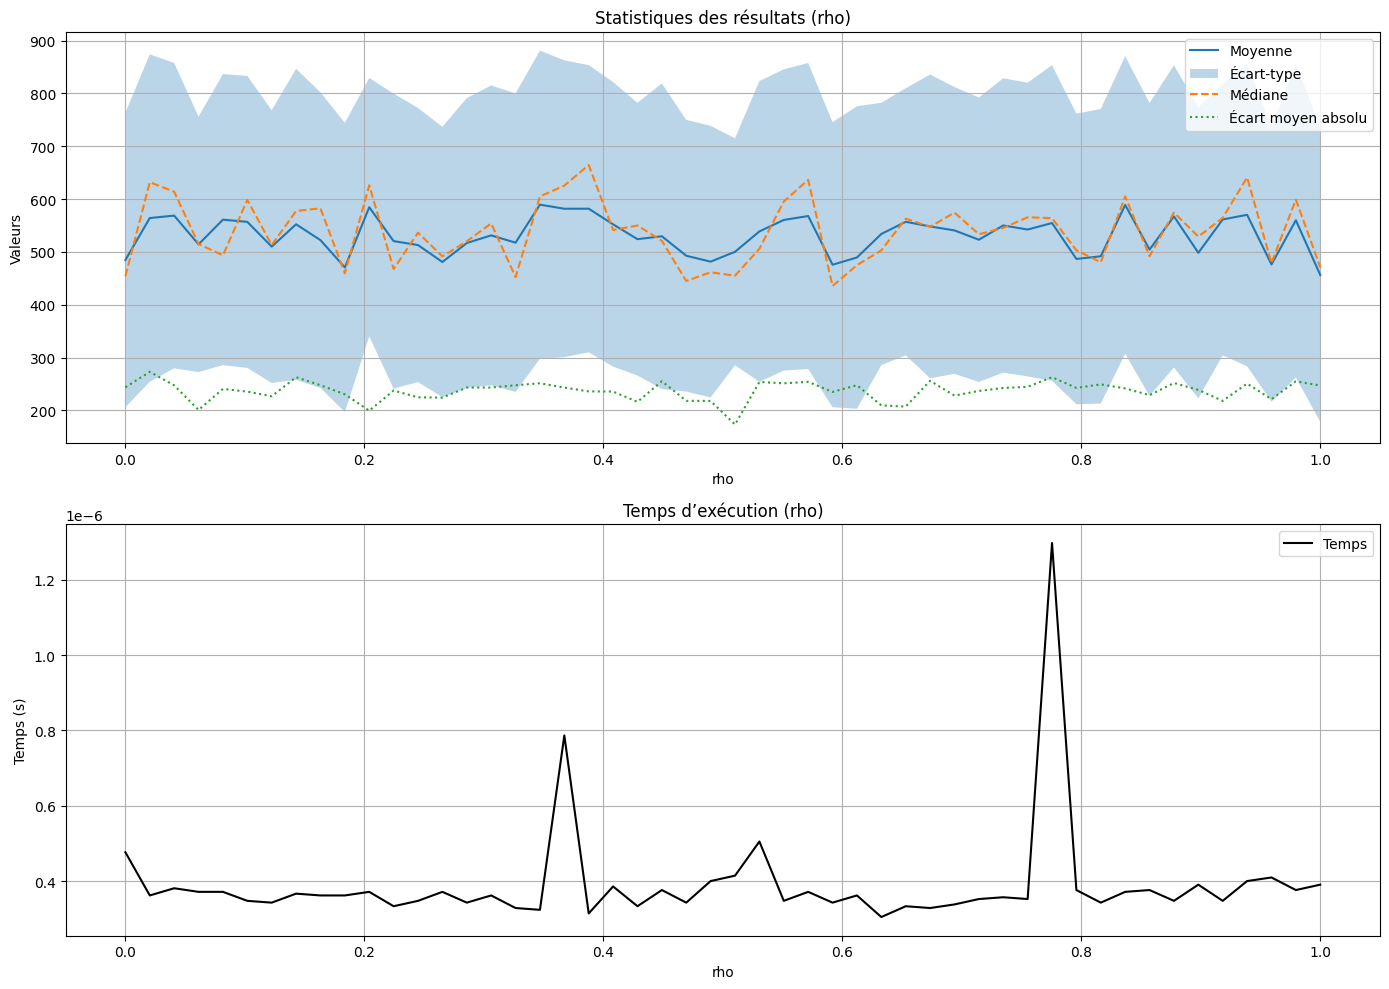

In [24]:
array_ants = np.linspace(1, 1000, 50)
array_it = np.linspace(1, 1000, 50)
array_alpha = np.linspace(0, 5, 50)
array_beta = np.linspace(1, 5, 50)
array_rho = np.linspace(0, 1, 50)


LMeanAnts, LStdAnts, LMedianAnts, LAbsMedianAnts, LTpsMeanAnts = execAlgoOneParam(n_iter, array_ants, "ant")
LMeanIt, LStdIt, LMedianIt, LAbsMedianIt, LTpsMeanIt = execAlgoOneParam(n_iter, array_it, "it")
LMeanAlpha, LStdAlpha, LMedianAlpha, LAbsMedianAlpha, LTpsMeanAlpha = execAlgoOneParam(n_iter, array_alpha, "alpha")
LMeanBeta, LStdBeta, LMedianBeta, LAbsMedianBeta, LTpsMeanBeta = execAlgoOneParam(n_iter, array_beta, "beta")
LMeanRho, LStdRho, LMedianRho, LAbsMedianRho, LTpsMeanRho = execAlgoOneParam(n_iter, array_rho, "rho")

plotOneParam(array_ants, LMeanAnts, LStdAnts, LMedianAnts, LAbsMedianAnts, LTpsMeanAnts, "ant")
plotOneParam(array_it, LMeanIt, LStdIt, LMedianIt, LAbsMedianIt, LTpsMeanIt, "itérations")
plotOneParam(array_alpha, LMeanAlpha, LStdAlpha, LMedianAlpha, LAbsMedianAlpha, LTpsMeanAlpha, "alpha")
plotOneParam(array_beta, LMeanBeta, LStdBeta, LMedianBeta, LAbsMedianBeta, LTpsMeanBeta, "beta")
plotOneParam(array_rho, LMeanRho, LStdRho, LMedianRho, LAbsMedianRho, LTpsMeanRho, "rho")

